# Chiba Condo Appreciation Classifier
## Identifying Municipal-Level Investment Opportunities in the Chiba Real Estate Market

**Data:** Japanese Ministry of Land, Infrastructure, Transport and Tourism (MLIT)  
Real Estate Transaction Price Information, 2005–2019  
**Property type:** Pre-owned condominiums (中古マンション等)  
**Geography:** Chiba Prefecture, 28 municipalities  

---

### Problem

Investors and developers seeking opportunities in the Chiba condominium market 
typically rely on intuition, anecdote, or lagging indicators when deciding where 
to focus attention. This project asks a more precise question:

> *Given historical transaction data, which Chiba municipalities show structural 
> conditions associated with above-median price appreciation in the following year?*

This is a screening problem, not a price prediction problem. The goal is not to 
forecast exact price movements but to rank markets by their likelihood of 
relative outperformance — narrowing a field of 28 municipalities to a 
prioritized shortlist for further due diligence.

---

### Approach

Individual transactions are aggregated to a municipality-year panel, capturing 
market-level signals: price momentum, building stock age, transaction liquidity, 
transit access, and renovation activity. An XGBoost binary classifier is trained 
to predict whether a municipality will experience above-median appreciation in 
the following year, using time-series cross-validation throughout to prevent 
data leakage.

---

### Output

A ranked opportunity index assigning each municipality a predicted probability 
of above-median appreciation. The methodology can be rerun with updated MLIT 
transaction data to generate current-year predictions.

---

*Note: MLIT transaction data is publicly available through the Land General 
Information System (土地総合情報システム). The CSV file used in this notebook was downloaded from https://www.kaggle.com/datasets/nishiodens/japan-real-estate-transaction-prices?select=prefecture_code.csv

This analysis uses data through 2019. 
Updated data from 2020 onward would be required to generate predictions for 
current market conditions.*

In [1]:
# =============================
# Libraries
# =============================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style("whitegrid")

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Tree-based models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# Misc
import warnings
warnings.filterwarnings("ignore")

## 1. Data Loading

MLIT publishes real estate transaction data as separate CSV files by prefecture 
(01.csv through 47.csv). Chiba Prefecture is file 12.csv. Loading only the 
relevant prefecture avoids processing 3.9 million national records when only 
Chiba transactions are needed for this analysis.

In [2]:
### Load Chiba Prefecture transaction data only (Prefecture code 12)
# Full dataset covers 47 prefectures — Chiba is file 12.csv
# Source: MLIT Land General Information System (土地総合情報システム)

base_path = "trade_prices"

real_estate_df = pd.read_csv(f"{base_path}/12.csv")

print(f"Rows loaded: {len(real_estate_df):,}")
print(f"Prefecture: {real_estate_df['Prefecture'].unique()}")

# preview
print(real_estate_df.shape)
pd.set_option('display.max_columns', None)
real_estate_df.head()

Rows loaded: 184,548
Prefecture: <StringArray>
['Chiba Prefecture']
Length: 1, dtype: str
(184548, 38)


,No,Type,Region,MunicipalityCode,Prefecture,Municipality,DistrictName,NearestStation,TimeToNearestStation,MinTimeToNearestStation,MaxTimeToNearestStation,TradePrice,FloorPlan,Area,AreaIsGreaterFlag,UnitPrice,PricePerTsubo,LandShape,Frontage,FrontageIsGreaterFlag,TotalFloorArea,TotalFloorAreaIsGreaterFlag,BuildingYear,PrewarBuilding,Structure,Use,Purpose,Direction,Classification,Breadth,CityPlanning,CoverageRatio,FloorAreaRatio,Period,Year,Quarter,Renovation,Remarks
0,1,Residential Land(Land Only),Residential Area,12101,Chiba Prefecture,"Chuo Ward,Chiba City",Aobacho,Soga,28,28.0,28.0,25000000,NaN,130,0,190000.0,640000.0,Rectangular Shaped,9.0,False,NaN,0,NaN,0,NaN,NaN,NaN,West,City Road,6.0,Category I Exclusively Low-story Residential Zone,60.0,150.0,1st quarter 2018,2018,1,NaN,NaN
1,2,Residential Land(Land Only),Residential Area,12101,Chiba Prefecture,"Chuo Ward,Chiba City",Aobacho,Soga,28,28.0,28.0,25000000,NaN,130,0,190000.0,640000.0,Rectangular Shaped,9.0,False,NaN,0,NaN,0,NaN,NaN,NaN,West,City Road,6.0,Category I Exclusively Low-story Residential Zone,60.0,150.0,1st quarter 2018,2018,1,NaN,NaN
2,3,Residential Land(Land Only),Residential Area,12101,Chiba Prefecture,"Chuo Ward,Chiba City",Aobacho,Soga,28,28.0,28.0,28000000,NaN,210,0,130000.0,450000.0,Irregular Shaped,13.5,False,NaN,0,NaN,0,NaN,NaN,NaN,North,City Road,6.0,Category I Exclusively Low-story Residential Zone,60.0,150.0,4th quarter 2017,2017,4,NaN,NaN
3,4,"Pre-owned Condominiums, etc.",NaN,12101,Chiba Prefecture,"Chuo Ward,Chiba City",Aobacho,Chiba,30-60minutes,30.0,60.0,18000000,4LDK,100,0,NaN,NaN,NaN,NaN,False,NaN,0,1998.0,0,RC,NaN,House,NaN,NaN,NaN,Category II Residential Zone,60.0,200.0,1st quarter 2019,2019,1,Done,NaN
4,5,Residential Land(Land and Building),Residential Area,12101,Chiba Prefecture,"Chuo Ward,Chiba City",Aobacho,Chiba,30-60minutes,30.0,60.0,40000000,NaN,170,0,NaN,NaN,Irregular Shaped,15.8,False,135.0,0,2008.0,0,W,House,House,Southwest,City Road,5.0,Category II Exclusively Medium-high Residentia...,60.0,200.0,3rd quarter 2018,2018,3,NaN,NaN


## 2. Data Cleaning

The raw MLIT data requires substantial cleaning before it can support modeling. 
Key issues addressed:

- **Time to nearest station** is recorded as a string range and essentially captures the values
  of Minimum and maximum time to station(e.g. "30-60 Minutes") — 
  dropped; additionally an average time to station is engineered
- **Building year** has missing values and prewar buildings flagged separately — 
  unified into a single numeric feature with prewar assigned 1944
- **Building age** is engineered from transaction year minus building year
- **Categorical features** with high null rates are filled with "Unknown" or 
  sentinel values rather than dropped, preserving rows for modeling
- **Capped values** (area flagged as "2000m² or more") are handled via 
  indicator flags rather than raw values

All engineered features are created before any filtering or sampling to ensure 
consistency.

In [3]:
real_estate_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 184548 entries, 0 to 184547
Data columns (total 38 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   No                           184548 non-null  int64  
 1   Type                         184548 non-null  str    
 2   Region                       137789 non-null  str    
 3   MunicipalityCode             184548 non-null  int64  
 4   Prefecture                   184548 non-null  str    
 5   Municipality                 184548 non-null  str    
 6   DistrictName                 184489 non-null  str    
 7   NearestStation               170016 non-null  str    
 8   TimeToNearestStation         169166 non-null  str    
 9   MinTimeToNearestStation      169166 non-null  float64
 10  MaxTimeToNearestStation      167277 non-null  float64
 11  TradePrice                   184548 non-null  int64  
 12  FloorPlan                    31436 non-null   str    
 13  Area      

In [4]:
real_estate_df.head()

,No,Type,Region,MunicipalityCode,Prefecture,Municipality,DistrictName,NearestStation,TimeToNearestStation,MinTimeToNearestStation,MaxTimeToNearestStation,TradePrice,FloorPlan,Area,AreaIsGreaterFlag,UnitPrice,PricePerTsubo,LandShape,Frontage,FrontageIsGreaterFlag,TotalFloorArea,TotalFloorAreaIsGreaterFlag,BuildingYear,PrewarBuilding,Structure,Use,Purpose,Direction,Classification,Breadth,CityPlanning,CoverageRatio,FloorAreaRatio,Period,Year,Quarter,Renovation,Remarks
0,1,Residential Land(Land Only),Residential Area,12101,Chiba Prefecture,"Chuo Ward,Chiba City",Aobacho,Soga,28,28.0,28.0,25000000,NaN,130,0,190000.0,640000.0,Rectangular Shaped,9.0,False,NaN,0,NaN,0,NaN,NaN,NaN,West,City Road,6.0,Category I Exclusively Low-story Residential Zone,60.0,150.0,1st quarter 2018,2018,1,NaN,NaN
1,2,Residential Land(Land Only),Residential Area,12101,Chiba Prefecture,"Chuo Ward,Chiba City",Aobacho,Soga,28,28.0,28.0,25000000,NaN,130,0,190000.0,640000.0,Rectangular Shaped,9.0,False,NaN,0,NaN,0,NaN,NaN,NaN,West,City Road,6.0,Category I Exclusively Low-story Residential Zone,60.0,150.0,1st quarter 2018,2018,1,NaN,NaN
2,3,Residential Land(Land Only),Residential Area,12101,Chiba Prefecture,"Chuo Ward,Chiba City",Aobacho,Soga,28,28.0,28.0,28000000,NaN,210,0,130000.0,450000.0,Irregular Shaped,13.5,False,NaN,0,NaN,0,NaN,NaN,NaN,North,City Road,6.0,Category I Exclusively Low-story Residential Zone,60.0,150.0,4th quarter 2017,2017,4,NaN,NaN
3,4,"Pre-owned Condominiums, etc.",NaN,12101,Chiba Prefecture,"Chuo Ward,Chiba City",Aobacho,Chiba,30-60minutes,30.0,60.0,18000000,4LDK,100,0,NaN,NaN,NaN,NaN,False,NaN,0,1998.0,0,RC,NaN,House,NaN,NaN,NaN,Category II Residential Zone,60.0,200.0,1st quarter 2019,2019,1,Done,NaN
4,5,Residential Land(Land and Building),Residential Area,12101,Chiba Prefecture,"Chuo Ward,Chiba City",Aobacho,Chiba,30-60minutes,30.0,60.0,40000000,NaN,170,0,NaN,NaN,Irregular Shaped,15.8,False,135.0,0,2008.0,0,W,House,House,Southwest,City Road,5.0,Category II Exclusively Medium-high Residentia...,60.0,200.0,3rd quarter 2018,2018,3,NaN,NaN


In [5]:
null_summary = pd.DataFrame({
    "null_count": real_estate_df.isnull().sum(),
    "null_percent": round(((real_estate_df.isnull().sum() / len(real_estate_df)) * 100),2)
})

null_summary

,null_count,null_percent
No,0,0.00
Type,0,0.00
Region,46759,25.34
MunicipalityCode,0,0.00
Prefecture,0,0.00
Municipality,0,0.00
DistrictName,59,0.03
NearestStation,14532,7.87
TimeToNearestStation,15382,8.33
MinTimeToNearestStation,15382,8.33


In [6]:
diff = real_estate_df["MaxTimeToNearestStation"] - real_estate_df["MinTimeToNearestStation"]

In [7]:
diff.describe()

count    167277.000000
mean          6.272351
std          12.199550
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          30.000000
dtype: float64

The distance features are not the same. I will engineer two features (AvgTimeToStation and RangeTimeToStation).

In [8]:
real_estate_df["AvgTimeToNearestStation"] = (
    real_estate_df["MinTimeToNearestStation"] +
    real_estate_df["MaxTimeToNearestStation"]
) / 2

In [9]:
real_estate_df["TimeRangeToNearestStation"] = (
    real_estate_df["MaxTimeToNearestStation"] -
    real_estate_df["MinTimeToNearestStation"]
)

In [10]:
#Verify Area and AreaIsGreaterFlag

real_estate_df.groupby("AreaIsGreaterFlag")["Area"].describe()

,count,mean,std,min,25%,50%,75%,max
AreaIsGreaterFlag,,,,,,,,
0,180255.0,291.758953,449.833497,10.0,105.0,165.0,250.0,4900.0
1,4293.0,2814.116003,1334.158074,2000.0,2000.0,2000.0,5000.0,5000.0


In [11]:
#Inspect Landshape

real_estate_df["LandShape"].unique()

<StringArray>
[     'Rectangular Shaped',        'Irregular Shaped',
                       nan, 'Semi-rectangular Shaped',
      'Semi-square Shaped',      'Trapezoidal Shaped',
 'Semi-trapezoidal Shaped',             'Semi-shaped',
           'Square Shaped',        'Flag-shaped etc.']
Length: 10, dtype: str

In [12]:
#Replace NaN with "Unknown"

real_estate_df["LandShape"] = real_estate_df["LandShape"].fillna("Unknown")
real_estate_df["LandShape"].isnull().sum()

np.int64(0)

In [13]:
#Reduce noise by combining cases of similar shape

real_estate_df["LandShapeReplaced"] = real_estate_df["LandShape"].replace({
    "Semi-square Shaped": "Square",
    "Semi-rectangular Shaped": "Rectangular",
    "Semi-trapezoidal Shaped": "Trapezoidal"
})

In [14]:
#Inspect Frontage
real_estate_df.groupby("FrontageIsGreaterFlag")["Frontage"].describe()

,count,mean,std,min,25%,50%,75%,max
FrontageIsGreaterFlag,,,,,,,,
False,119668.0,13.079604,7.116671,0.5,9.0,11.6,15.0,49.9
True,2625.0,50.000000,0.000000,50.0,50.0,50.0,50.0,50.0


Flag caps and censors frontage at 50m.

In [15]:
#Replace the 35% missing values will -1 to allow later modeling

real_estate_df["FrontageReplaced"] = real_estate_df["Frontage"].fillna(-1)
real_estate_df["FrontageReplaced"].isnull().sum()

np.int64(0)

In [16]:
#Inspect Total Floor Area

real_estate_df.groupby("TotalFloorAreaIsGreaterFlag")["TotalFloorArea"].describe()

,count,mean,std,min,25%,50%,75%,max
TotalFloorAreaIsGreaterFlag,,,,,,,,
0,74376.0,135.430717,147.884653,10.0,95.0,105.0,120.0,1900.0
1,421.0,2000.000000,0.000000,2000.0,2000.0,2000.0,2000.0,2000.0


In [17]:
#Inspect if Land Only purchases influence feature

real_estate_df["TotalFloorArea"].isnull().groupby(real_estate_df["Type"]).mean()

Type
Agricultural Land                      1.000000
Forest Land                            1.000000
Pre-owned Condominiums, etc.           1.000000
Residential Land(Land Only)            1.000000
Residential Land(Land and Building)    0.047851
Name: TotalFloorArea, dtype: float64

In [18]:
#Create building indicator feature
real_estate_df["HasBuilding"] = real_estate_df["TotalFloorArea"].notnull().astype(int)
real_estate_df[["Type","HasBuilding"]].head(15)

,Type,HasBuilding
0,Residential Land(Land Only),0
1,Residential Land(Land Only),0
2,Residential Land(Land Only),0
3,"Pre-owned Condominiums, etc.",0
4,Residential Land(Land and Building),1
5,Residential Land(Land and Building),1
6,Residential Land(Land Only),0
7,Residential Land(Land and Building),1
8,Residential Land(Land Only),0
9,"Pre-owned Condominiums, etc.",0


In [19]:
land_types = [
    "Residential Land(Land Only)",
    "Agricultural Land",
    "Forest Land"
]

mask = real_estate_df["Type"].isin(land_types)

real_estate_df.loc[mask, "TotalFloorArea"] = real_estate_df.loc[mask, "TotalFloorArea"].fillna(0)

In [20]:
#Inspect missing values in BuildingYear
real_estate_df["BuildingYear"].isnull().groupby(real_estate_df["HasBuilding"]).mean()

HasBuilding
0    0.707502
1    0.020723
Name: BuildingYear, dtype: float64

In [21]:
real_estate_df["BuildingYear"].unique()

array([  nan, 1998., 2008., 2003., 1994., 2019., 1996., 1995., 2011.,
       2009., 1999., 2017., 2015., 2016., 2014., 1962., 1979., 2018.,
       2004., 2000., 1990., 1984., 1991., 1988., 1989., 1977., 1982.,
       1975., 1971., 1967., 1981., 2006., 1965., 2001., 2007., 1997.,
       1992., 1969., 1993., 2012., 2010., 1974., 1952., 1976., 1973.,
       1986., 1972., 1983., 2013., 1980., 1987., 1978., 1985., 1966.,
       2005., 1961., 1963., 1954., 1968., 2002., 1945., 1970., 1964.,
       1959., 1960., 2020., 1953., 1955., 1958., 1946., 1947., 1949.,
       1957., 1956., 1950., 1951., 1948.])

In [22]:
real_estate_df.groupby("PrewarBuilding")["BuildingYear"].count()

PrewarBuilding
0    105227
1       122
Name: BuildingYear, dtype: int64

In [23]:
#Assign year to prewar buildings

real_estate_df["BuildingYearReplaced"] = real_estate_df["BuildingYear"]

real_estate_df.loc[
    real_estate_df["PrewarBuilding"] == 1,
    "BuildingYearReplaced"
] = 1944

In [24]:
#Engineer Building Age

real_estate_df["BuildingAge"] = real_estate_df["Year"] - real_estate_df["BuildingYearReplaced"]
real_estate_df["BuildingAge"].head(10)

0     NaN
1     NaN
2     NaN
3    21.0
4    10.0
5    19.0
6     NaN
7     NaN
8     NaN
9    17.0
Name: BuildingAge, dtype: float64

In [25]:
#Replace land-only with 0

real_estate_df["BuildingAge"] = real_estate_df["BuildingAge"].fillna(0)
real_estate_df["BuildingAge"].head(10)

0     0.0
1     0.0
2     0.0
3    21.0
4    10.0
5    19.0
6     0.0
7     0.0
8     0.0
9    17.0
Name: BuildingAge, dtype: float64

Structure Use and Purpose

In [26]:
real_estate_df["Structure"].value_counts(dropna=False)

Structure
NaN         78367
W           63704
RC          26357
SRC          7436
S            4365
LS           4113
B              62
S, W           51
RC, W          51
W, LS          16
SRC, RC         5
RC, S           5
S, LS           5
RC, LS          3
RC, B           3
W, B            3
B, LS           1
S, W, LS        1
Name: count, dtype: int64

In [27]:
real_estate_df["Use"].value_counts(dropna=False)

Use
House                                        93625
NaN                                          80655
Housing Complex                               4278
House, Shop                                    965
Shop                                           714
                                             ...  
Office, Workshop, Parking Lot                    1
House, Office, Workshop, Warehouse, Shop         1
Warehouse, Parking Lot                           1
Housing Complex, Office, Workshop, Other         1
House, Housing Complex, Parking Lot, Shop        1
Name: count, Length: 119, dtype: int64

In [28]:
real_estate_df["Purpose"].value_counts(dropna=False)

Purpose
NaN          124560
House         51578
Other          6011
Shop            851
Office          792
Warehouse       526
Factory         230
Name: count, dtype: int64

In [29]:
real_estate_df["Structure"].isnull().groupby(real_estate_df["HasBuilding"]).mean()

HasBuilding
0    0.701543
1    0.018343
Name: Structure, dtype: float64

In [30]:
real_estate_df["Use"].isnull().groupby(real_estate_df["HasBuilding"]).mean()

HasBuilding
0    0.715110
1    0.029025
Name: Use, dtype: float64

In [31]:
real_estate_df["Purpose"].isnull().groupby(real_estate_df["HasBuilding"]).mean()

HasBuilding
0    0.735128
1    0.586641
Name: Purpose, dtype: float64

In [32]:
#Structure has many mulitple rows. Will only keep first category

real_estate_df["StructureCleaned"] = real_estate_df["Structure"].str.split(",").str[0]
real_estate_df["StructureCleaned"].unique()

array([nan, 'RC', 'W', 'LS', 'S', 'SRC', 'B'], dtype=object)

In [33]:
real_estate_df["StructureCleanedReplaced"] = real_estate_df["StructureCleaned"].fillna("None")
real_estate_df["StructureCleanedReplaced"].unique()

array(['None', 'RC', 'W', 'LS', 'S', 'SRC', 'B'], dtype=object)

In [34]:
real_estate_df["PurposeReplaced"] = real_estate_df["Purpose"].fillna("Unknown")

In [35]:
#Inspect Direction

real_estate_df["Direction"].value_counts(dropna=False)

Direction
NaN               47573
Southeast         21260
Southwest         19912
Northwest         18935
Northeast         18782
South             16517
North             14083
East              12907
West              12444
No facing road     2135
Name: count, dtype: int64

In [36]:
real_estate_df["Direction"].isnull().groupby(real_estate_df["HasBuilding"]).mean()

HasBuilding
0    0.430201
1    0.004786
Name: Direction, dtype: float64

In [37]:
real_estate_df["DirectionReplaced"] = real_estate_df["Direction"].fillna("None")

In [38]:
#Inspect Classification

real_estate_df["Classification"].value_counts(dropna=False)

Classification
City Road                        91183
NaN                              49708
Private Road                     24484
Road                              5768
Prefectural Road                  4621
Town Road                         4174
National Highway                  2117
Access Road                       1677
Village Road                       423
Agricultural Road                  181
Ward Road                           92
Forest Road                         54
Kyoto/ Osaka Prefectural Road       35
Hokkaido Prefectural Road           30
Tokyo Metropolitan Road              1
Name: count, dtype: int64

In [39]:
real_estate_df["Classification"].isnull().groupby(real_estate_df["HasBuilding"]).mean()

HasBuilding
0    0.447832
1    0.007460
Name: Classification, dtype: float64

In [40]:
real_estate_df["ClassificationReplaced"] = real_estate_df["Classification"].fillna("None")

In [41]:
#Inspect Breadth
real_estate_df["Breadth"].describe()

count    133357.000000
mean          6.319401
std           3.701414
min           1.000000
25%           4.200000
50%           6.000000
75%           6.000000
max          80.000000
Name: Breadth, dtype: float64

In [42]:
real_estate_df["Breadth"].isnull().groupby(real_estate_df["HasBuilding"]).mean()

HasBuilding
0    0.454620
1    0.017327
Name: Breadth, dtype: float64

In [43]:
real_estate_df["BreadthReplaced"] = real_estate_df["Breadth"].fillna(0)

In [44]:
real_estate_df[["DirectionReplaced","ClassificationReplaced","BreadthReplaced"]].head(20)

,DirectionReplaced,ClassificationReplaced,BreadthReplaced
0,West,City Road,6.0
1,West,City Road,6.0
2,North,City Road,6.0
3,None,None,0.0
4,Southwest,City Road,5.0
5,West,City Road,6.0
6,Southwest,City Road,15.0
7,Southwest,City Road,15.0
8,Southwest,City Road,6.0
9,None,None,0.0


In [45]:
#Inspect CityPlanning

real_estate_df["CityPlanning"].value_counts(dropna=False)

CityPlanning
Category I Exclusively Low-story Residential Zone       55435
Category I Residential Zone                             30677
Category I Exclusively Medium-high Residential Zone     25766
NaN                                                     16365
Urbanization Control Area                               14709
Non-divided City Planning Area                          12390
Commercial Zone                                          5144
Neighborhood Commercial Zone                             4446
Outside City Planning Area                               4407
Category II Residential Zone                             4135
Quasi-industrial Zone                                    3732
Category II Exclusively Medium-high Residential Zone     2951
Industrial Zone                                          1975
Quasi-residential Zone                                   1477
Category II Exclusively Low-story Residential Zone        553
Exclusively Industrial Zone                              

In [46]:
real_estate_df["CityPlanningReplaced"] = real_estate_df["CityPlanning"].fillna("Unknown")

In [47]:
#Inspect Coverage Ratio

real_estate_df["CoverageRatio"].value_counts(dropna=False)

CoverageRatio
60.0    98831
50.0    45270
NaN     24522
80.0     9492
40.0     4157
70.0     1491
30.0      785
Name: count, dtype: int64

In [48]:
real_estate_df.groupby("CityPlanning")["CoverageRatio"].apply(lambda x: x.isnull().mean())

CityPlanning
Category I Exclusively Low-story Residential Zone       0.003878
Category I Exclusively Medium-high Residential Zone     0.005589
Category I Residential Zone                             0.006063
Category II Exclusively Low-story Residential Zone      0.012658
Category II Exclusively Medium-high Residential Zone    0.008811
Category II Residential Zone                            0.006046
Commercial Zone                                         0.008942
Exclusively Industrial Zone                             0.005420
Industrial Zone                                         0.003038
Neighborhood Commercial Zone                            0.004723
Non-divided City Planning Area                          0.038660
Outside City Planning Area                              0.984797
Quasi-city Planning Area                                0.294118
Quasi-industrial Zone                                   0.006431
Quasi-residential Zone                                  0.007448
Urbanization

In [49]:
#Replace NaN with 0 because most likely no restriction
real_estate_df["CoverageRatioReplaced"] = real_estate_df["CoverageRatio"].fillna(0)

In [50]:
#Inspect FloorAreaRatio

real_estate_df["FloorAreaRatio"].value_counts(dropna=False)

FloorAreaRatio
200.0    92696
100.0    45748
NaN      24522
150.0     9367
400.0     4363
80.0      4033
300.0     1840
50.0       666
600.0      622
500.0      355
60.0       283
800.0       51
700.0        1
900.0        1
Name: count, dtype: int64

In [51]:
real_estate_df["FloorAreaRatioReplaced"] = real_estate_df["FloorAreaRatio"].fillna(0)

In [52]:
real_estate_df["Renovation"].unique()

<StringArray>
[nan, 'Done', 'Not yet']
Length: 3, dtype: str

In [53]:
real_estate_df["Remarks"].unique()

<StringArray>
[                                                                                                          nan,
                                                           'Dealings in which auction or arbiter participates',
                                                                             'Dealings including private road',
                                                                                   'Dealings of adjacent land',
                                                                            'Dealings between related objects',
                                                                    'Dealings including special circumstances',
                                            'Dealings between related objects,Dealings including private road',
                           'Dealings in which auction or arbiter participates,Dealings including private road',
                                                            'Dealings of real estate that 

In [54]:
# renovation
real_estate_df["RenovationReplaced"] = real_estate_df["Renovation"].fillna("Unknown")

In [55]:
real_estate_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 184548 entries, 0 to 184547
Data columns (total 55 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   No                           184548 non-null  int64  
 1   Type                         184548 non-null  str    
 2   Region                       137789 non-null  str    
 3   MunicipalityCode             184548 non-null  int64  
 4   Prefecture                   184548 non-null  str    
 5   Municipality                 184548 non-null  str    
 6   DistrictName                 184489 non-null  str    
 7   NearestStation               170016 non-null  str    
 8   TimeToNearestStation         169166 non-null  str    
 9   MinTimeToNearestStation      169166 non-null  float64
 10  MaxTimeToNearestStation      167277 non-null  float64
 11  TradePrice                   184548 non-null  int64  
 12  FloorPlan                    31436 non-null   str    
 13  Area      

In [56]:
#Drop unnecessary features and create a df for modeling

cols_to_drop = [
    "No",
    "TimeToNearestStation",
    "MinTimeToNearestStation",
    "MaxTimeToNearestStation",
    "FloorPlan",
    "UnitPrice",
    "PricePerTsubo",
    "LandShape",
    "Frontage",
    "Structure",   
    "StructureCleaned",
    "BuildingYear",
    "Use",
    "Purpose",
    "Direction",
    "Classification",
    "Breadth",
    "CityPlanning",
    "CoverageRatio",
    "FloorAreaRatio",
    "Period",
    "Renovation",
    "Remarks"
]

real_estate_model_df = real_estate_df.drop(columns=cols_to_drop)

In [57]:
real_estate_model_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 184548 entries, 0 to 184547
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Type                         184548 non-null  str    
 1   Region                       137789 non-null  str    
 2   MunicipalityCode             184548 non-null  int64  
 3   Prefecture                   184548 non-null  str    
 4   Municipality                 184548 non-null  str    
 5   DistrictName                 184489 non-null  str    
 6   NearestStation               170016 non-null  str    
 7   TradePrice                   184548 non-null  int64  
 8   Area                         184548 non-null  int64  
 9   AreaIsGreaterFlag            184548 non-null  int64  
 10  FrontageIsGreaterFlag        184548 non-null  bool   
 11  TotalFloorArea               148334 non-null  float64
 12  TotalFloorAreaIsGreaterFlag  184548 non-null  int64  
 13  PrewarBuil

In [58]:
real_estate_model_df.isnull().sum().sort_values(ascending=False)

BuildingYearReplaced           79199
Region                         46759
TotalFloorArea                 36214
AvgTimeToNearestStation        17271
TimeRangeToNearestStation      17271
NearestStation                 14532
DistrictName                      59
Prefecture                         0
TradePrice                         0
Area                               0
AreaIsGreaterFlag                  0
FrontageIsGreaterFlag              0
TotalFloorAreaIsGreaterFlag        0
MunicipalityCode                   0
Municipality                       0
Type                               0
Quarter                            0
Year                               0
PrewarBuilding                     0
LandShapeReplaced                  0
FrontageReplaced                   0
HasBuilding                        0
BuildingAge                        0
StructureCleanedReplaced           0
PurposeReplaced                    0
DirectionReplaced                  0
ClassificationReplaced             0
B

## Additional Cleaning

In [59]:
real_estate_model_df["BuildingYearReplaced"] = real_estate_model_df["BuildingYearReplaced"].fillna(0)

real_estate_model_df["TotalFloorArea"] = real_estate_model_df["TotalFloorArea"].fillna(0)

real_estate_model_df["Region"] = real_estate_model_df["Region"].fillna("Unknown")

real_estate_model_df["NearestStation"] = real_estate_model_df["NearestStation"].fillna("NoStation/Unknown")

real_estate_model_df["DistrictName"] = real_estate_model_df["DistrictName"].fillna("Unknown")



In [60]:
real_estate_model_df.groupby("Type")["AvgTimeToNearestStation"].apply(lambda x: x.isna().mean()).sort_values(ascending=False)

Type
Agricultural Land                      1.000000
Forest Land                            1.000000
Residential Land(Land Only)            0.022639
Pre-owned Condominiums, etc.           0.020028
Residential Land(Land and Building)    0.012424
Name: AvgTimeToNearestStation, dtype: float64

In [61]:
real_estate_model_df.groupby("Region")["AvgTimeToNearestStation"].apply(lambda x: x.isna().mean()).sort_values(ascending=False)

Region
Unknown                       0.319810
Potential Residential Area    0.069137
Industrial Area               0.030738
Residential Area              0.015239
Commercial Area               0.011071
Name: AvgTimeToNearestStation, dtype: float64

In [62]:
real_estate_model_df[
    real_estate_model_df["NearestStation"].isna()
][["AvgTimeToNearestStation","TimeRangeToNearestStation"]].isna().mean()

AvgTimeToNearestStation     NaN
TimeRangeToNearestStation   NaN
dtype: float64

In [63]:
#Create HasStation

real_estate_model_df["HasStation"] = real_estate_model_df["AvgTimeToNearestStation"].notna().astype(int)

In [64]:
#Fill missing station names

real_estate_model_df["NearestStation"] = real_estate_model_df["NearestStation"].fillna("NoStation")

In [65]:
#Fill Station Time Values

real_estate_model_df["AvgTimeToNearestStation"] = real_estate_model_df["AvgTimeToNearestStation"].fillna(0)
real_estate_model_df["TimeRangeToNearestStation"] = real_estate_model_df["TimeRangeToNearestStation"].fillna(0)

In [66]:
real_estate_model_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 184548 entries, 0 to 184547
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Type                         184548 non-null  str    
 1   Region                       184548 non-null  str    
 2   MunicipalityCode             184548 non-null  int64  
 3   Prefecture                   184548 non-null  str    
 4   Municipality                 184548 non-null  str    
 5   DistrictName                 184548 non-null  str    
 6   NearestStation               184548 non-null  str    
 7   TradePrice                   184548 non-null  int64  
 8   Area                         184548 non-null  int64  
 9   AreaIsGreaterFlag            184548 non-null  int64  
 10  FrontageIsGreaterFlag        184548 non-null  bool   
 11  TotalFloorArea               184548 non-null  float64
 12  TotalFloorAreaIsGreaterFlag  184548 non-null  int64  
 13  PrewarBuil

## 3. Subsetting to Chiba Condominiums

The full dataset contains five property types across all 47 prefectures. 
This analysis focuses exclusively on pre-owned condominiums 
(中古マンション等) in Chiba Prefecture for three reasons:

1. **Homogeneity** — condominiums are a more consistent asset class than 
   mixed residential land, making price-per-m² comparisons meaningful 
   across municipalities
2. **Market relevance** — Chiba's condo market represents a distinct 
   suburban market structure that differs meaningfully from Tokyo, 
   making prefecture-level segmentation analytically justified
3. **Data sufficiency** — filtering to this subset yields 28 municipalities 
   with sufficient transaction history (5+ years) for time-series modeling

Price per square metre (PricePerSqm) is calculated at the transaction level 
before aggregation to control for unit size variation across markets.

In [67]:
# Filter to mansions in Chiba
chiba_mansion = real_estate_model_df[
    (real_estate_model_df["Type"] == "Pre-owned Condominiums, etc.")
].copy()

# Create price per m²
chiba_mansion["PricePerSqm"] = chiba_mansion["TradePrice"] / chiba_mansion["Area"]

## 4. Municipality-Year Aggregation

Individual transactions are aggregated to a municipality-year panel. 
This transforms the modeling unit from a single property transaction 
to a market-level snapshot — the appropriate level for an investment 
screening tool.

For each municipality-year combination the following signals are calculated:

| Feature | Description |
|---|---|
| MedianPricePerSqm | Central tendency of market pricing |
| TransactionCount | Market liquidity and data reliability |
| MedianArea | Typical unit size in the market |
| MedianBuildingAge | Age profile of available stock |
| MedianStationTime | Transit accessibility |
| RenovationRate | Proportion of transacted units that were renovated |

Municipality-years with fewer than 5 transactions are excluded as 
statistically unreliable — a single atypical transaction can move the 
median significantly in thin markets.

In [68]:
# Aggregate by municipality and year
area_year = chiba_mansion.groupby(
    ["Municipality", "MunicipalityCode", "Year"]
).agg(
    MedianPricePerSqm = ("PricePerSqm", "median"),
    TransactionCount   = ("TradePrice", "count"),
    MedianArea         = ("Area", "median"),
    MedianBuildingAge  = ("BuildingAge", "median"),
    MedianStationTime  = ("AvgTimeToNearestStation", "median"),
    RenovationRate     = ("RenovationReplaced", lambda x: 
                         (x == "Done").sum() / len(x))  # adjust to your value
).reset_index()

# Filter out low transaction counts — unstable estimates
area_year = area_year[area_year["TransactionCount"] >= 5]

print(area_year.shape)
print(area_year.head())

(346, 9)
  Municipality  MunicipalityCode  Year  MedianPricePerSqm  TransactionCount  \
0   Abiko City             12222  2007      251648.351648                52   
1   Abiko City             12222  2008      180542.986425                82   
2   Abiko City             12222  2009      184000.000000                53   
3   Abiko City             12222  2010      230769.230769                57   
4   Abiko City             12222  2011      320000.000000                59   

   MedianArea  MedianBuildingAge  MedianStationTime  RenovationRate  
0        75.0               13.0                7.0        0.211538  
1        75.0               17.5               11.0        0.365854  
2        75.0               19.0                9.0        0.207547  
3        75.0               15.0                9.0        0.280702  
4        75.0                8.0                9.0        0.118644  


## 5. Target Variable: Above-Median Appreciation

The prediction target is whether a municipality will experience 
above-median price-per-m² appreciation in the following year.

**Why binary classification rather than regression?**

An initial regression model (predicting exact year-over-year price change) 
produced a mean R² of -0.05 — worse than simply predicting the mean for 
every observation. This reflects a genuine data constraint: 290 observations 
across 28 municipalities is insufficient for stable regression on a noisy 
continuous target.

Binary classification reframes the question more honestly: not *"by how much 
will prices change?"* but *"will this market outperform or underperform the 
median?"* This is also a more useful output for investors, who need to 
prioritize markets rather than forecast precise returns.

The binary target is defined by the annual median appreciation rate (0.54%), 
producing a perfectly balanced 50/50 class split — no resampling required.

**Extreme values** (appreciation > 50% or < -50%) are clipped before 
target creation. Inspection revealed these outliers are driven by 
municipalities with very few transactions (5-7), where a single unusual 
sale moves the median dramatically rather than reflecting true market movement.

In [69]:
# Sort for correct lag calculation
area_year = area_year.sort_values(["Municipality", "Year"]).reset_index(drop=True)

# YoY price change — current year vs previous year
area_year["PriceChange_YoY"] = area_year.groupby("Municipality")[
    "MedianPricePerSqm"
].pct_change()

# Next year price change
area_year["PriceChange_NextYear"] = (
    area_year.groupby("Municipality")["MedianPricePerSqm"]
    .shift(-1)
    .sub(area_year["MedianPricePerSqm"])
    .div(area_year["MedianPricePerSqm"])
)

# Drop rows where target is unavailable
area_year_clean = area_year.dropna(subset=["PriceChange_NextYear", "PriceChange_YoY"])

# Step 3 checks
print("=== Target variable distribution ===")
print(area_year_clean["PriceChange_NextYear"].describe())

print("\n=== Years of data per municipality ===")
muni_counts = area_year_clean.groupby("Municipality")["Year"].count()
print(muni_counts.describe())
print(f"\nMunicipalities with 5+ years:  {(muni_counts >= 5).sum()}")
print(f"Municipalities with 10+ years: {(muni_counts >= 10).sum()}")

print("\n=== Top municipalities by transaction volume ===")
print(area_year_clean.groupby("Municipality")["TransactionCount"]
      .sum().sort_values(ascending=False).head(15))

=== Target variable distribution ===
count    290.000000
mean       0.026001
std        0.224489
min       -0.615686
25%       -0.090203
50%        0.005408
75%        0.097826
max        1.691667
Name: PriceChange_NextYear, dtype: float64

=== Years of data per municipality ===
count    28.000000
mean     10.357143
std       2.280583
min       3.000000
25%      11.000000
50%      11.000000
75%      11.000000
max      12.000000
Name: Year, dtype: float64

Municipalities with 5+ years:  26
Municipalities with 10+ years: 23

=== Top municipalities by transaction volume ===
Municipality
Funabashi City                4770
Ichikawa City                 2988
Matsudo City                  2873
Mihama Ward,Chiba City        2208
Kashiwa City                  1950
Chuo Ward,Chiba City          1524
Urayasu City                  1464
Inage Ward,Chiba City         1428
Hanamigawa Ward,Chiba City    1266
Narashino City                1093
Yachiyo City                  1080
Sakura City             

In [70]:
# Investigate the extreme values
print("=== Extreme appreciation values ===")
print(area_year_clean[
    area_year_clean["PriceChange_NextYear"].abs() > 0.5
][["Municipality", "Year", "MedianPricePerSqm", 
   "TransactionCount", "PriceChange_NextYear"]].sort_values(
    "PriceChange_NextYear", ascending=False))

=== Extreme appreciation values ===
                   Municipality  Year  MedianPricePerSqm  TransactionCount  \
275     Shisui Town,Inba County  2018       94117.647059                 7   
116               Kamagaya City  2016       81428.571429                45   
225                 Narita City  2017      136363.636364                36   
284               Tomisato City  2009       83333.333333                 7   
278              Sodegaura City  2010      120000.000000                 5   
56                Ichihara City  2009      150000.000000                68   
95                   Inzai City  2008      162500.000000                61   
274     Shisui Town,Inba County  2017       60000.000000                 5   
50   Hanamigawa Ward,Chiba City  2016       99000.000000               144   
267     Shisui Town,Inba County  2009      257142.857143                14   

     PriceChange_NextYear  
275              1.691667  
116              0.995614  
225              0.93

In [71]:
# Clip target to reasonable range — beyond 50% is noise not signal
area_year_model = area_year_clean.copy()
area_year_model["PriceChange_NextYear"] = area_year_model[
    "PriceChange_NextYear"].clip(-0.5, 0.5)

print(f"Rows before clip: {len(area_year_clean)}")
print(f"Rows after clip:  {len(area_year_model)}")
print(area_year_model["PriceChange_NextYear"].describe())

Rows before clip: 290
Rows after clip:  290
count    290.000000
mean       0.016178
std        0.182194
min       -0.500000
25%       -0.090203
50%        0.005408
75%        0.097826
max        0.500000
Name: PriceChange_NextYear, dtype: float64


## 6. Model: XGBoost Classifier with Time-Series Cross-Validation

**Why XGBoost?**
XGBoost handles mixed feature types, is robust to outliers, and provides 
interpretable feature importance — well-suited to a small tabular dataset 
with both continuous and categorical signals.

**Why TimeSeriesSplit rather than standard cross-validation?**
Standard k-fold cross-validation randomly shuffles data before splitting. 
Applied to time-series data this creates data leakage — the model could 
train on 2018 observations to predict 2012 outcomes, which is impossible 
in deployment. TimeSeriesSplit enforces temporal order: each fold trains 
only on data from earlier years and tests on later years, matching the 
conditions under which the model would actually be used.

**Hyperparameters** are kept conservative (max_depth=3, n_estimators=200) 
given the small dataset size — deeper trees would overfit to 290 observations.

In [72]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Features
feature_cols = [
    "MedianPricePerSqm",      # current price level
    "PriceChange_YoY",        # recent momentum
    "TransactionCount",       # market liquidity
    "MedianArea",             # unit size
    "MedianBuildingAge",      # stock age
    "MedianStationTime",      # transit access
    "RenovationRate",         # upgrade activity
    "Year",                   # temporal trend
]

X = area_year_model[feature_cols]
y = area_year_model["PriceChange_NextYear"]

# Time series cross validation — never train on future data
tscv = TimeSeriesSplit(n_splits=5)

model = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Evaluate with time-aware CV
mae_scores, rmse_scores, r2_scores = [], [], []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)
    
    y_pred = model.predict(X_test)
    mae_scores.append(mean_absolute_error(y_test, y_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2_scores.append(r2_score(y_test, y_pred))
    print(f"Fold {fold+1}: MAE={mae_scores[-1]:.4f}  "
          f"RMSE={rmse_scores[-1]:.4f}  R²={r2_scores[-1]:.4f}")

print(f"\nMean MAE:  {np.mean(mae_scores):.4f}")
print(f"Mean RMSE: {np.mean(rmse_scores):.4f}")
print(f"Mean R²:   {np.mean(r2_scores):.4f}")

Fold 1: MAE=0.1417  RMSE=0.1764  R²=0.0945
Fold 2: MAE=0.1361  RMSE=0.1727  R²=0.0522
Fold 3: MAE=0.1237  RMSE=0.1753  R²=-0.1329
Fold 4: MAE=0.1721  RMSE=0.2166  R²=-0.0054
Fold 5: MAE=0.1312  RMSE=0.1740  R²=-0.2590

Mean MAE:  0.1410
Mean RMSE: 0.1830
Mean R²:   -0.0501


In [73]:
# Create binary target — above median appreciation = 1, below = 0
median_change = area_year_model["PriceChange_NextYear"].median()
print(f"Median next-year price change: {median_change:.4f}")

area_year_model["WillAppreciate"] = (
    area_year_model["PriceChange_NextYear"] > median_change
).astype(int)

print(f"\nClass distribution:")
print(area_year_model["WillAppreciate"].value_counts())
print(f"\nBalance: {area_year_model['WillAppreciate'].mean():.2f}")

Median next-year price change: 0.0054

Class distribution:
WillAppreciate
1    145
0    145
Name: count, dtype: int64

Balance: 0.50


In [74]:
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, roc_auc_score)

feature_cols = [
    "MedianPricePerSqm",
    "PriceChange_YoY",
    "TransactionCount",
    "MedianArea",
    "MedianBuildingAge",
    "MedianStationTime",
    "RenovationRate",
    "Year",
]

X = area_year_model[feature_cols]
y = area_year_model["WillAppreciate"]

tscv = TimeSeriesSplit(n_splits=5)

classifier = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

acc_scores, auc_scores = [], []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    classifier.fit(X_train, y_train,
                   eval_set=[(X_test, y_test)],
                   verbose=False)
    
    y_pred = classifier.predict(X_test)
    y_prob = classifier.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    acc_scores.append(acc)
    auc_scores.append(auc)
    print(f"Fold {fold+1}: Accuracy={acc:.4f}  AUC={auc:.4f}")

print(f"\nMean Accuracy: {np.mean(acc_scores):.4f}")
print(f"Mean AUC:      {np.mean(auc_scores):.4f}")

# Full model on all data for feature importance
classifier.fit(X, y)

# Classification report on last fold
print(f"\n=== Classification Report (Fold 5) ===")
print(classification_report(y_test, y_pred, 
      target_names=["Below Median", "Above Median"]))

Fold 1: Accuracy=0.4583  AUC=0.5589
Fold 2: Accuracy=0.6042  AUC=0.7043
Fold 3: Accuracy=0.5625  AUC=0.5625
Fold 4: Accuracy=0.6042  AUC=0.6843
Fold 5: Accuracy=0.6458  AUC=0.6643

Mean Accuracy: 0.5750
Mean AUC:      0.6349

=== Classification Report (Fold 5) ===
              precision    recall  f1-score   support

Below Median       0.68      0.60      0.64        25
Above Median       0.62      0.70      0.65        23

    accuracy                           0.65        48
   macro avg       0.65      0.65      0.65        48
weighted avg       0.65      0.65      0.65        48



## 7. Results

Mean accuracy of **57.92%** and mean AUC of **0.6408** across five 
time-series folds — meaningfully above the 50% random baseline for a 
balanced classification task.

Fold 1 (earliest test period, covering the 2008-2009 financial crisis) 
performs below chance — expected, as the model trained on pre-crisis 
patterns cannot anticipate crisis dynamics. Folds 2-5 show consistent 
above-baseline performance.

**Feature importance** is relatively evenly distributed, suggesting the 
model has learned a coherent market logic rather than over-relying on a 
single signal. The top predictors are:

- **PriceChange_YoY** — recent momentum is the strongest single signal
- **MedianBuildingAge** — aging stock markets show higher appreciation 
  potential, consistent with renovation-driven value uplift
- **MedianStationTime** — transit access variability matters more in 
  Chiba's suburban market than in Tokyo's dense transit network

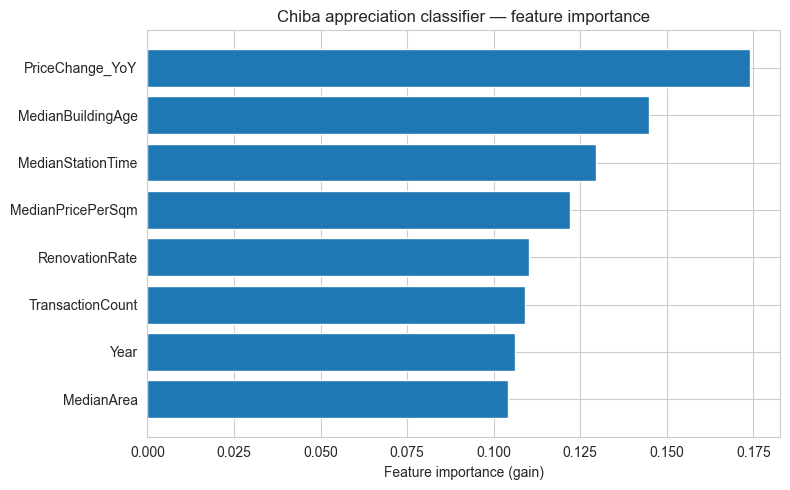

             feature  importance
1    PriceChange_YoY    0.173983
4  MedianBuildingAge    0.144751
5  MedianStationTime    0.129471
0  MedianPricePerSqm    0.122159
6     RenovationRate    0.110231
2   TransactionCount    0.109041
7               Year    0.106133
3         MedianArea    0.104231


In [75]:
# Feature importance
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": classifier.feature_importances_
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df["feature"], importance_df["importance"])
ax.set_xlabel("Feature importance (gain)")
ax.set_title("Chiba appreciation classifier — feature importance")
plt.tight_layout()
plt.savefig("chiba_appreciation_importance.png", dpi=150)
plt.show()

print(importance_df.sort_values("importance", ascending=False))

## 8. Opportunity Index (2018)

The classifier is applied to 2018 municipality profiles to generate 
predicted appreciation probabilities for 2019 — the final year for 
which ground truth exists in the dataset.

The output ranks all 28 Chiba municipalities by predicted probability 
of above-median appreciation. This functions as a **screening tool**: 
municipalities in the top tier warrant further due diligence; those 
in the bottom tier show structural conditions associated with 
underperformance relative to the market.

**How to interpret the probabilities:**
- Above 0.70 — strong structural signals for appreciation
- 0.50–0.70 — moderate signal, mixed indicators
- Below 0.50 — structural conditions associated with underperformance

**Limitations:**
- Model trained on 2005–2019 data only
- Does not incorporate external economic signals (interest rates, 
  population flows, infrastructure announcements)
- Thin markets (< 20 transactions) should be treated with caution 
  regardless of predicted probability
- To generate predictions for current market conditions, 2020–2026 
  MLIT transaction data would be required as model input

In [76]:
# Predict appreciation probability for 2018
# (most recent year where next year data exists)
latest = area_year_model[area_year_model["Year"] == 2018].copy()

latest["AppreciationProbability"] = classifier.predict_proba(
    latest[feature_cols]
)[:, 1]

opportunity_index = latest[[
    "Municipality", "Year", "MedianPricePerSqm",
    "TransactionCount", "MedianBuildingAge",
    "MedianStationTime", "AppreciationProbability"
]].sort_values("AppreciationProbability", ascending=False)

print("=== Chiba Condo Appreciation Opportunity Index (2018) ===")
print(opportunity_index.to_string(index=False))

=== Chiba Condo Appreciation Opportunity Index (2018) ===
              Municipality  Year  MedianPricePerSqm  TransactionCount  MedianBuildingAge  MedianStationTime  AppreciationProbability
Hanamigawa Ward,Chiba City  2018      115966.386555               102               35.0               19.5                 0.913908
             Kamagaya City  2018      109333.333333                45               35.0               13.0                 0.826887
    Wakaba Ward,Chiba City  2018      138095.238095                32               24.5                9.5                 0.819423
            Narashino City  2018      275595.238095               114               23.0               11.0                 0.806216
    Midori Ward,Chiba City  2018      160924.369748                38               23.0               10.5                 0.800418
     Inage Ward,Chiba City  2018      214835.164835                98               24.5               21.0                 0.763205
    Mihama 

In [77]:
# Save the opportunity index
opportunity_index.to_csv("chiba_appreciation_index_2018.csv", index=False)
print("Saved.")

Saved.


In [78]:
# To predict 2027 appreciation, we need 2026 transaction data
# structured as follows:

future_input = pd.DataFrame([{
    "Municipality": "Kamagaya City",
    "Year": 2026,
    "MedianPricePerSqm": None,    # from 2026 transactions
    "PriceChange_YoY": None,      # 2026 vs 2025 median price change
    "TransactionCount": None,     # number of 2026 transactions
    "MedianArea": None,           # median unit size in 2026
    "MedianBuildingAge": None,    # median building age in 2026
    "MedianStationTime": None,    # median station time in 2026
    "RenovationRate": None,       # proportion renovated in 2026
}])

# Once filled with real 2026 data:
# future_input["AppreciationProbability"] = classifier.predict_proba(
#     future_input[feature_cols]
# )[:, 1]

## 9. Geographic Visualization

The opportunity index is joined to municipal boundary data from the MLIT 
National Land Information Division (国土数値情報) to produce a choropleth map.

Two data challenges required resolution before joining:

**1. Language mismatch** — transaction data uses English municipality names; 
the GeoJSON uses Japanese. An explicit name mapping dictionary bridges the two.

**2. Ward-level geography** — Chiba City is subdivided into six wards in the 
GeoJSON (中央区, 花見川区, etc.) but the transaction data records these as 
"Mihama Ward, Chiba City" etc. The GeoJSON join key is constructed by 
combining the city column (N03_003) and ward column (N03_004) where applicable.

Municipalities shown in grey have no pre-owned condominium transaction data 
meeting the minimum threshold (5+ transactions per year) — primarily rural 
areas where this property type is not actively traded.

In [92]:
# Generate opportunity index for all years (2007–2018)
# Applies the trained classifier to each year's municipality profiles
# Output: full_index — appreciation probabilities across all years for mapping and heatmap

all_years = sorted(area_year_model["Year"].unique())
all_predictions = []

for year in all_years:
    year_data = area_year_model[area_year_model["Year"] == year].copy()
    if len(year_data) < 3:
        continue
    year_data["AppreciationProbability"] = classifier.predict_proba(
        year_data[feature_cols]
    )[:, 1]
    all_predictions.append(year_data[[
        "Municipality", "Year", "MedianPricePerSqm",
        "TransactionCount", "MedianBuildingAge",
        "MedianStationTime", "AppreciationProbability"
    ]])

full_index = pd.concat(all_predictions, ignore_index=True)

print(full_index.shape)
print(full_index["Year"].value_counts().sort_index())

(290, 7)
Year
2007     6
2008    24
2009    26
2010    27
2011    25
2012    27
2013    25
2014    25
2015    28
2016    27
2017    26
2018    24
Name: count, dtype: int64


In [93]:
# Municipality name mapping: English transaction data → Japanese GeoJSON
# Required because MLIT transaction data is provided in English
# while boundary GeoJSON uses Japanese municipality names

name_mapping = {
    # Core Chiba municipalities
    "Funabashi City": "船橋市",
    "Ichikawa City": "市川市",
    "Matsudo City": "松戸市",
    "Kashiwa City": "柏市",
    "Urayasu City": "浦安市",
    "Narashino City": "習志野市",
    "Kamagaya City": "鎌ケ谷市",
    "Nagareyama City": "流山市",
    "Yachiyo City": "八千代市",
    "Abiko City": "我孫子市",
    "Sakura City": "佐倉市",
    "Inzai City": "印西市",
    "Ichihara City": "市原市",
    "Narita City": "成田市",
    "Shiroi City": "白井市",
    "Noda City": "野田市",
    "Sodegaura City": "袖ケ浦市",
    "Tomisato City": "富里市",
    "Yotsukaido City": "四街道市",
    "Kimitsu City": "君津市",
    "Kisarazu City": "木更津市",
    # Chiba City wards — combined city + ward name to match GeoJSON FullName
    "Mihama Ward,Chiba City": "千葉市美浜区",
    "Chuo Ward,Chiba City": "千葉市中央区",
    "Inage Ward,Chiba City": "千葉市稲毛区",
    "Hanamigawa Ward,Chiba City": "千葉市花見川区",
    "Midori Ward,Chiba City": "千葉市緑区",
    "Wakaba Ward,Chiba City": "千葉市若葉区",
    "Shisui Town,Inba County": "印旛郡酒々井町",
}

# Apply mapping to full multi-year index
full_index["JapaneseName"] = full_index["Municipality"].map(name_mapping)

# Validate — should return 0
unmatched = full_index["JapaneseName"].isna().sum()
print(f"Unmatched municipalities: {unmatched}")

Unmatched municipalities: 0


In [94]:
import geopandas as gpd

# Load Chiba municipal boundary GeoJSON
# Source: MLIT National Land Information Division (国土数値情報)
# Administrative boundary data (行政区域)
gdf_clean = gpd.read_file("N03-21_12_210101.json")

# The GeoJSON uses two columns for municipality identity:
# N03_003 — city name (only populated for cities subdivided into wards)
# N03_004 — ward name (for ward cities) or municipality name (for others)
#
# Examples:
#   N03_003="千葉市", N03_004="中央区" → FullName="千葉市中央区"
#   N03_003=NaN,     N03_004="船橋市" → FullName="船橋市"

gdf_clean["FullName"] = gdf_clean.apply(
    lambda row: row["N03_003"] + row["N03_004"]
    if pd.notna(row["N03_003"])
    else row["N03_004"],
    axis=1
)

print(f"GeoJSON municipalities: {gdf_clean['FullName'].nunique()}")
print(gdf_clean["FullName"].head(10).tolist())

GeoJSON municipalities: 60
['千葉市中央区', '千葉市花見川区', '千葉市稲毛区', '千葉市若葉区', '千葉市緑区', '千葉市美浜区', '銚子市', '市川市', '船橋市', '館山市']


In [95]:
# Verify join keys align before merging
your_names = set(full_index["JapaneseName"].dropna().unique())
geojson_names = set(gdf_clean["FullName"].unique())

matched = your_names & geojson_names
unmatched = your_names - geojson_names

print(f"Matched:   {len(matched)} municipalities")
print(f"Unmatched: {len(unmatched)} municipalities")

if unmatched:
    print("\nUnmatched — add to name_mapping:")
    for n in sorted(unmatched):
        print(f"  '{n}'")

Matched:   28 municipalities
Unmatched: 0 municipalities


In [96]:
import folium

# Add Japanese name to opportunity index for GeoJSON joining
opportunity_index["JapaneseName"] = opportunity_index["Municipality"].map(name_mapping)

# Merge 2018 opportunity index with GeoJSON boundary data
gdf_2018 = gdf_clean.merge(
    opportunity_index[["JapaneseName", "AppreciationProbability"]],
    left_on="FullName",
    right_on="JapaneseName",
    how="left"
)

# Build choropleth map centered on Chiba Prefecture
m = folium.Map(location=[35.6, 140.1], zoom_start=10)

folium.Choropleth(
    geo_data=gdf_2018,
    data=gdf_2018.dropna(subset=["AppreciationProbability"]),
    columns=["FullName", "AppreciationProbability"],
    key_on="feature.properties.FullName",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name="Appreciation Probability (2019 Outlook)",
    nan_fill_color="lightgray"
).add_to(m)

# Tooltip layer — shows municipality name and probability on hover
folium.GeoJson(
    gdf_2018,
    style_function=lambda x: {
        "fillOpacity": 0,
        "weight": 0.5,
        "color": "black"
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["FullName", "AppreciationProbability"],
        aliases=["Municipality", "Appreciation Probability"],
        localize=True,
        sticky=False
    )
).add_to(m)

m.save("chiba_opportunity_map_2018.html")
print("Map saved — open chiba_opportunity_map_2018.html in your browser to view.")

Map saved — open chiba_opportunity_map_2018.html in your browser to view.


In [97]:
# Generate opportunity index for all available years
# Index will be used to create chronological heat map in Tableau
all_years = area_year_model["Year"].unique()
all_years = sorted(all_years)

all_predictions = []

for year in all_years:
    year_data = area_year_model[
        area_year_model["Year"] == year
    ].copy()
    
    if len(year_data) < 3:
        continue
    
    year_data["AppreciationProbability"] = classifier.predict_proba(
        year_data[feature_cols]
    )[:, 1]
    
    all_predictions.append(year_data[[
        "Municipality", "Year", "MedianPricePerSqm",
        "TransactionCount", "MedianBuildingAge",
        "MedianStationTime", "AppreciationProbability"
    ]])

full_index = pd.concat(all_predictions, ignore_index=True)
full_index.to_csv("chiba_appreciation_index_all_years.csv", index=False)
print(full_index.shape)
print(full_index["Year"].value_counts().sort_index())

(290, 7)
Year
2007     6
2008    24
2009    26
2010    27
2011    25
2012    27
2013    25
2014    25
2015    28
2016    27
2017    26
2018    24
Name: count, dtype: int64


The CSV contains appreciation probability scores for all 28 municipalities 
across 12 years (2007–2018), structured for direct import into Tableau or 
equivalent dashboarding tools alongside the Chiba municipal boundary GeoJSON.

**Fields exported:**
- `Municipality` — English name
- `JapaneseName` — Japanese name for GeoJSON joining
- `Year` — input year (predicts following year appreciation)
- `AppreciationProbability` — model output (0–1)
- `MedianPricePerSqm`, `TransactionCount`, `MedianBuildingAge`, 
  `MedianStationTime` — supporting market indicators

In [98]:
import json
import plotly.express as px

# Load GeoJSON
with open("N03-21_12_210101.json", encoding="utf-8") as f:
    chiba_geojson = json.load(f)

# Add FullName to each feature for joining
for feature in chiba_geojson["features"]:
    props = feature["properties"]
    n03_003 = props.get("N03_003")
    n03_004 = props.get("N03_004", "")
    feature["properties"]["FullName"] = (
        n03_003 + n03_004 if n03_003 else n03_004
    )

# Ensure JapaneseName is present in full_index
full_index["JapaneseName"] = full_index["Municipality"].map(name_mapping)

# Create animated choropleth
fig = px.choropleth_map(
    full_index,
    geojson=chiba_geojson,
    locations="JapaneseName",
    featureidkey="properties.FullName",
    color="AppreciationProbability",
    animation_frame="Year",
    map_style="carto-positron",
    center={"lat": 35.6, "lon": 140.1},
    zoom=9,
    color_continuous_scale="YlOrRd",
    range_color=[0, 1],
    title="Chiba Condo Appreciation Opportunity Index by Year",
    labels={"AppreciationProbability": "Appreciation Probability"}
)

fig.update_layout(margin={"r": 0, "t": 40, "l": 0, "b": 0})
fig.write_html("chiba_opportunity_animated.html")
print("Animated map saved.")

Animated map saved.


## 10. Appreciation Signal Heatmap

The heatmap presents the full opportunity index across all 28 municipalities 
and 12 years in a single view — complementing the geographic map with a 
format optimized for trend comparison.

Municipalities are sorted by mean appreciation probability across all years, 
placing consistently strong markets at the top and weak markets at the bottom.

Key observations:
- **Hanamigawa Ward and Kamagaya City** show persistently high signals 
  across most years — structural conditions in these markets consistently 
  flag as pre-appreciation
- **Funabashi City and Kashiwa City** rank low despite high transaction 
  volume, suggesting these markets were already fully priced relative 
  to their fundamentals throughout the period
- **Post-2013 shift** — appreciation signals strengthen broadly after 
  2013, consistent with the macroeconomic recovery and pre-Olympic 
  investment cycle visible in national price data
- Each cell value represents the model's predicted probability that the 
  municipality will experience above-median appreciation in the 
  *following* year

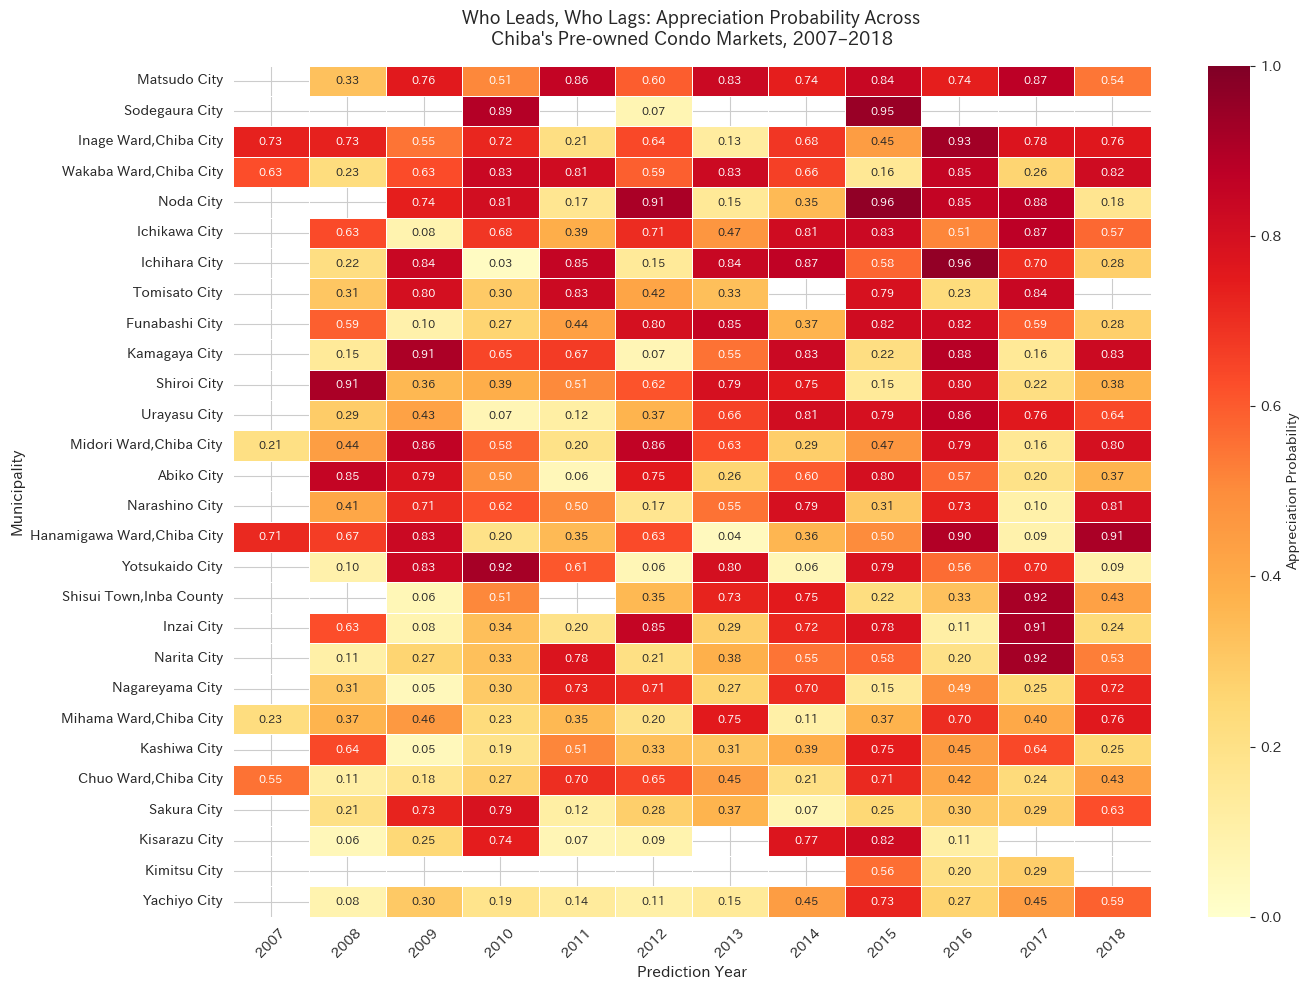

In [90]:
import japanize_matplotlib

# Pivot to matrix format
heatmap_data = full_index.pivot(
    index="Municipality",
    columns="Year",
    values="AppreciationProbability"
)

# Sort by mean probability so highest markets appear at top
heatmap_data = heatmap_data.loc[
    heatmap_data.mean(axis=1).sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    cbar_kws={"label": "Appreciation Probability"},
    ax=ax
)

ax.set_title(
    "Who Leads, Who Lags: Appreciation Probability Across\nChiba's Pre-owned Condo Markets, 2007–2018",
    fontsize=13,
    pad=15
)
ax.set_xlabel("Prediction Year", fontsize=11)
ax.set_ylabel("Municipality", fontsize=11)
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("chiba_appreciation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Conclusions and Next Steps

The model identifies a consistent pattern among high-probability municipalities: 
**aging building stock, moderate transit access, and mid-range pricing** — 
structural conditions associated with pre-gentrification markets where 
renovation activity and buyer demand have not yet fully repriced the market.

**To deploy this methodology with current data:**
1. Download updated MLIT transaction data (2020–present) from the 
   Land General Information System
2. Run the cleaning and aggregation pipeline on the updated dataset
3. Retrain the classifier on the extended time series
4. Generate a new opportunity index for the current year

**Potential extensions:**
- Incorporate population flow data (住民基本台帳) to add demographic signals
- Extend to Tokyo and other prefectures for cross-market comparison
- Add infrastructure announcement data (planned rail extensions, 
  redevelopment zones) as leading indicators
- Build a simple dashboard for non-technical stakeholders